In [37]:
import pandas as pd 
import numpy as np

In [38]:
df = pd.read_csv("loan approval prediction.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [40]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Categorical missing values  filled using mode (most frequent value).
Numerical missing values (LoanAmount)  filled using median to reduce skew impact.
Loan_ID  dropped because it's unique identifier, not useful for prediction.
After this step, dataset has no missing values in relevant columns.

In [41]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Married"] = df["Married"].fillna(df["Married"].mode()[0])
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0])
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

In [42]:
df = df.drop(columns=["Loan_ID"])

In [43]:
df['Credit_History'].value_counts()

Credit_History
1.0    525
0.0     89
Name: count, dtype: int64

In [44]:
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

Ensures all categorical columns are string type for encoding later.

In [45]:
df["Gender"] = df["Gender"].astype(str)
df["Married"] = df["Married"].astype(str)
df["Education"] = df["Education"].astype(str)
df["Self_Employed"] = df["Self_Employed"].astype(str)
df["Property_Area"] = df["Property_Area"].astype(str)
df["Loan_Status"] = df["Loan_Status"].astype(str)

In [46]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Visualization

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

Education vs Loan Status

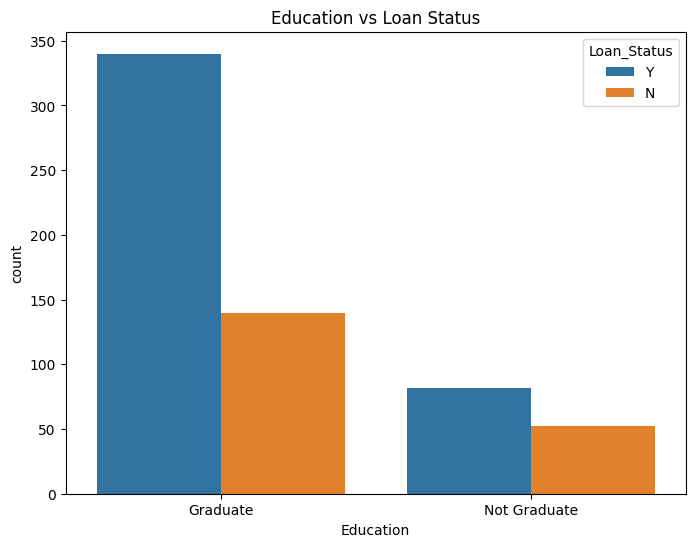

In [48]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x="Education", hue="Loan_Status")
plt.title("Education vs Loan Status")
plt.show()


loan approval between Graduate and Not Graduate.
Usually, Graduates get more loans approved.

Property Area vs Loan Status

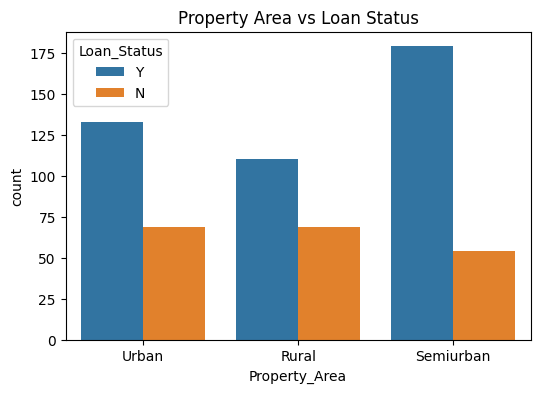

In [49]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Property_Area", hue="Loan_Status")
plt.title("Property Area vs Loan Status")
plt.show()


Shows loan approval across Urban, Semiurban, and Rural areas.
Semiurban usually has highest approvals, rural lowest.

Applicant Income Distribution

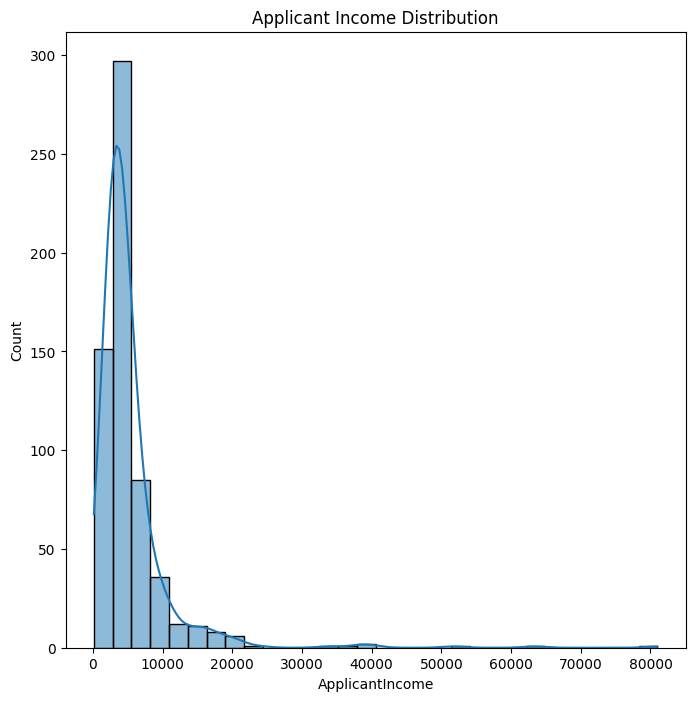

In [50]:
plt.figure(figsize=(8,8))
sns.histplot(df["ApplicantIncome"], bins=30, kde=True)
plt.title("Applicant Income Distribution")
plt.show()

Shows how the income of applicants is spread.     
Many people have low-to-moderate income, while few earn very high.

Gender Distribution

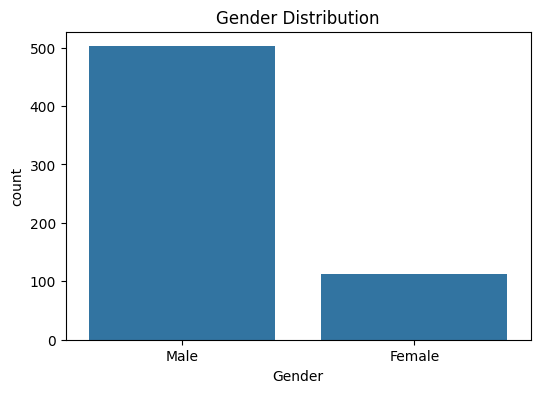

In [51]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Gender")
plt.title("Gender Distribution")
plt.show()


It shows how many Male vs Female applicants applied for loans.       
Usually, you will see more Male applicants than Female.

In [52]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Converts categorical features into numeric labels (0, 1, 2...).
Needed because machine learning models require numeric input.

In [53]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cols = ["Gender","Married","Education","Self_Employed","Property_Area","Loan_Status"]

for col in cols:
    df[col] = le.fit_transform(df[col])



In [54]:
df["Dependents"].unique()

array(['0', '1', '2', '3+'], dtype=object)

Converts "3+" to integer 3 for numerical operations.

In [55]:
df["Dependents"] = df["Dependents"].replace("3+", 3).astype(int)

In [56]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    int64  
 1   Married            614 non-null    int64  
 2   Dependents         614 non-null    int64  
 3   Education          614 non-null    int64  
 4   Self_Employed      614 non-null    int64  
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    int64  
 11  Loan_Status        614 non-null    int64  
dtypes: float64(4), int64(8)
memory usage: 57.7 KB


Correlation Heatmap

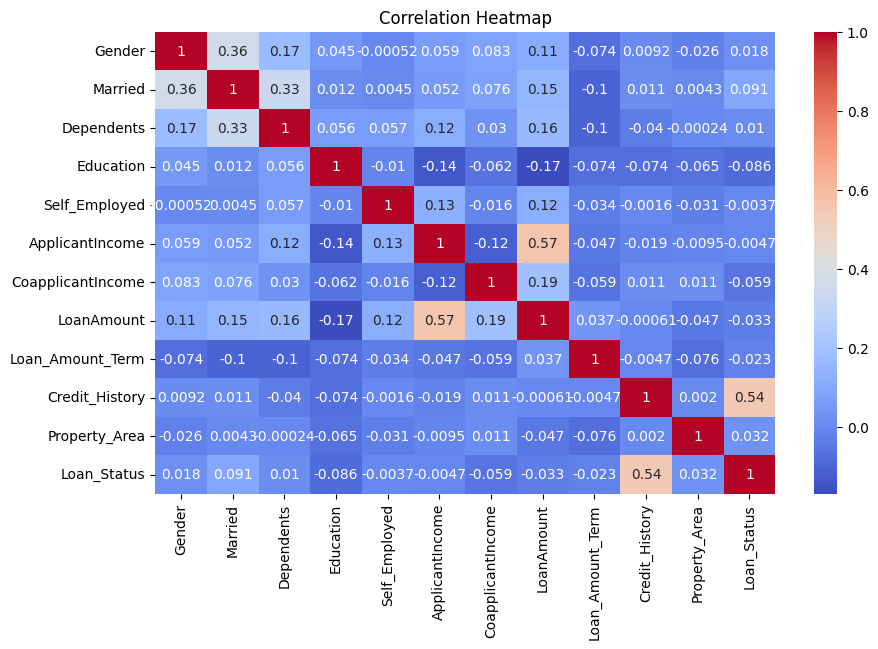

In [80]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


Shows relationships between numerical columns.     
High positive or negative values show strong relationships.

Standardizes numerical features to have mean = 0 and std = 1.
Helps models like Logistic Regression converge faster and improve accuracy.

In [58]:
from sklearn.preprocessing import StandardScaler

In [59]:
scaler = StandardScaler()
df[["ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term"]] = scaler.fit_transform(df[["ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term"]])

In [60]:
X = df.drop("Loan_Status",axis=1)
y = df["Loan_Status"]

In [61]:
X.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

In [62]:
from sklearn.model_selection import train_test_split

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [64]:
import numpy as np

print("Unique classes in y_train:", np.unique(y_train))
print("Counts:", np.unique(y_train, return_counts=True))

Unique classes in y_train: [0 1]
Counts: (array([0, 1]), array([149, 342]))


In [65]:
from sklearn.linear_model import LogisticRegression

Logistic Regression → a classification algorithm for binary target (Loan Approved: 1 / 0).

In [66]:
model_lr = LogisticRegression()
model_lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [67]:
y_pred = model_lr.predict(X_test)

In [68]:
model_lr.score(X_train,y_train)

0.8187372708757638

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

acc = accuracy_score(y_test, y_pred)
print("Accuracy Score:", acc)


Accuracy Score: 0.7886178861788617


In [70]:
from sklearn.model_selection import GridSearchCV

GridSearchCV  automatically finds the best combination of hyperparameters.

In [71]:
param_grid = {
    'C':[0.01, 0.1, 1, 10],
    'penalty':['l1','l2'],
    'solver':['liblinear','saga']
}

grid = GridSearchCV(LogisticRegression(max_iter=500), param_grid, cv=5)

In [72]:
grid.fit(X_train, y_train)
print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best Score: 0.8145949288806431


In [78]:
import joblib

joblib.dump(model_lr, "loan_approval_model.pkl")

['loan_approval_model.pkl']

In [79]:
joblib.dump(grid, "loan_approval_grid_model.pkl")

['loan_approval_grid_model.pkl']